# Notebook 2: ML Training — Wildfire Susceptibility

**Wildfire Susceptibility Mapping — Muğla Province, Turkey**  
CME434, Karabük University

**Purpose:** Train RF, XGBoost, SVM; compare; save best model  
**Input:** `Inputs.txt`, `Label.txt`  
**Output:** `best_model.pkl`, `scaler.pkl`

## Step 1 — Mount Drive & Install Libraries

In [11]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/GIS_Wildfire_Mugla'

!pip install xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay)
import xgboost as xgb
import joblib

print('Libraries loaded')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded


## Step 2 — Load Data

In [12]:
X = np.loadtxt(f'{DRIVE}/Inputs.txt')
y = np.loadtxt(f'{DRIVE}/Label.txt')

print(f'X: {X.shape}  |  y: {y.shape}')
vals, cnts = np.unique(y, return_counts=True)
print(f'Classes: burned={cnts[1]}  unburned={cnts[0]}')

X: (608, 15)  |  y: (608,)
Classes: burned=358  unburned=250


## Step 3 — 80/20 Train/Test Split and Scaling

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Burned in test: {int(y_test.sum())} / {len(y_test)}')

Train: (486, 15)  |  Test: (122, 15)
Burned in test: 72 / 122


## Step 4 — Classifier 1: Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             min_samples_split=4, max_features='sqrt',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
yp_rf = rf.predict(X_test)

print('--- Random Forest ---')
print(classification_report(y_test, yp_rf,
      target_names=['Unburned', 'Burned']))

--- Random Forest ---
              precision    recall  f1-score   support

    Unburned       0.98      0.84      0.90        50
      Burned       0.90      0.99      0.94        72

    accuracy                           0.93       122
   macro avg       0.94      0.91      0.92       122
weighted avg       0.93      0.93      0.93       122



## Step 5 — Classifier 2: XGBoost

In [15]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=7,
    colsample_bytree=0.8, subsample=0.8, min_child_weight=3,
    random_state=42, eval_metric='logloss', verbosity=0)
xgb_clf.fit(X_train, y_train)
yp_xgb = xgb_clf.predict(X_test)

print('--- XGBoost ---')
print(classification_report(y_test, yp_xgb,
      target_names=['Unburned', 'Burned']))

--- XGBoost ---
              precision    recall  f1-score   support

    Unburned       0.90      0.88      0.89        50
      Burned       0.92      0.93      0.92        72

    accuracy                           0.91       122
   macro avg       0.91      0.91      0.91       122
weighted avg       0.91      0.91      0.91       122



## Step 6 — Classifier 3: SVM

In [16]:
svm = SVC(kernel='rbf', C=10.0, gamma=0.01,
          probability=True, random_state=42)
svm.fit(X_train_s, y_train)
yp_svm = svm.predict(X_test_s)

print('--- SVM ---')
print(classification_report(y_test, yp_svm,
      target_names=['Unburned', 'Burned']))

--- SVM ---
              precision    recall  f1-score   support

    Unburned       0.97      0.70      0.81        50
      Burned       0.83      0.99      0.90        72

    accuracy                           0.87       122
   macro avg       0.90      0.84      0.86       122
weighted avg       0.89      0.87      0.86       122



## Step 7 — Comparison Table

In [17]:
def metrics(yp):
    return {
        'Accuracy':  round(accuracy_score(y_test, yp),  4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp),    4),
        'F1':        round(f1_score(y_test, yp),        4),
    }

results = pd.DataFrame([
    {'Model': 'Random Forest', **metrics(yp_rf)},
    {'Model': 'XGBoost',       **metrics(yp_xgb)},
    {'Model': 'SVM',           **metrics(yp_svm)},
]).sort_values('F1', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print(f'\nBest model: {results.iloc[0]["Model"]}')

        Model  Accuracy  Precision  Recall     F1
Random Forest    0.9262     0.8987  0.9861 0.9404
      XGBoost    0.9098     0.9178  0.9306 0.9241
          SVM    0.8689     0.8256  0.9861 0.8987

Best model: Random Forest


## Step 8 — Confusion Matrices

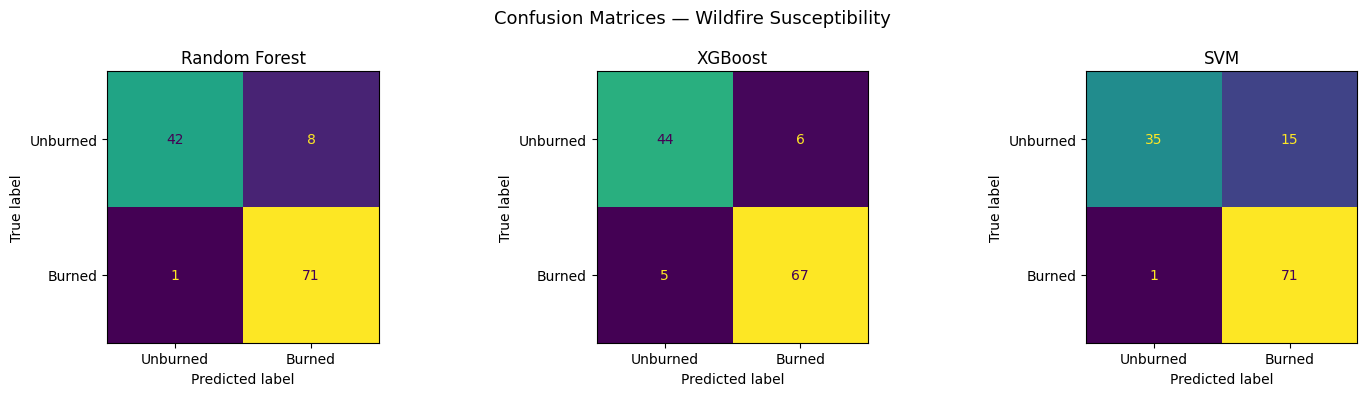

Saved: confusion_matrices.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, yp) in zip(axes, [
        ('Random Forest', yp_rf),
        ('XGBoost',       yp_xgb),
        ('SVM',           yp_svm)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, yp, ax=ax,
        display_labels=['Unburned', 'Burned'],
        colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices — Wildfire Susceptibility', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE}/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

## Step 9 — Feature Importance (Random Forest)

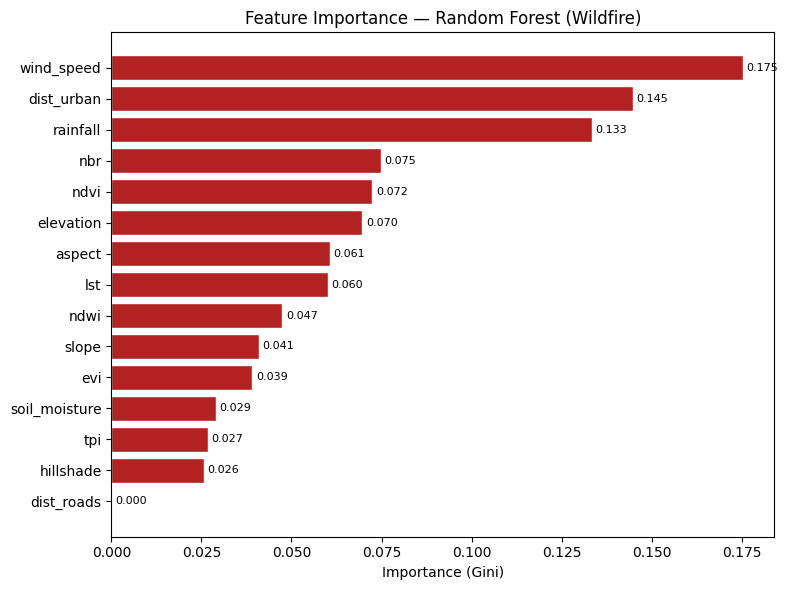

Saved: feature_importance.png


In [19]:
feat_names = [
    'elevation', 'slope', 'aspect', 'hillshade', 'tpi',
    'ndvi', 'ndwi', 'evi', 'nbr', 'wind_speed',
    'lst', 'dist_roads', 'dist_urban', 'rainfall', 'soil_moisture'
]

imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(imp.index, imp.values, color='firebrick', edgecolor='white')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Feature Importance — Random Forest (Wildfire)')
for b, v in zip(bars, imp.values):
    ax.text(v + 0.001, b.get_y() + b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{DRIVE}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

## Step 10 — Save Best Model

In [20]:
best_name = results.iloc[0]['Model']
best_model_obj = {'Random Forest': rf,
                  'XGBoost':       xgb_clf,
                  'SVM':           svm}[best_name]

joblib.dump(best_model_obj, f'{DRIVE}/best_model.pkl')
joblib.dump(scaler,         f'{DRIVE}/scaler.pkl')

print(f'Best model : {best_name}')
print(f'F1         : {results.iloc[0]["F1"]}')
print(f'Accuracy   : {results.iloc[0]["Accuracy"]}')
print(f'\nSaved: {DRIVE}/best_model.pkl')
print(f'Saved: {DRIVE}/scaler.pkl')
print('\nDone. Next: 03_susceptibility_map.ipynb')

Best model : Random Forest
F1         : 0.9404
Accuracy   : 0.9262

Saved: /content/drive/MyDrive/GIS_Wildfire_Mugla/best_model.pkl
Saved: /content/drive/MyDrive/GIS_Wildfire_Mugla/scaler.pkl

Done. Next: 03_susceptibility_map.ipynb
